# NLP Classification & Sentiment Analysis — Bacchanal Buffet

Amaç: restoran yorumlarının yıldızlardan türetilen negatif/nötr/pozitif sınıfını metinden öğrenmek; TextBlob ve VADER ile duygu analizi, kelime bulutları, ikili/üçlü kelime grupları ve işletme önerileri üretmek.

Kaynaklar: kullanıcının restaurant.csv, NLP_Sentiment-Analysis.docx, cloud.png ve wc.png dosyaları. DOCX bir örnek proje sunumudur; oradaki satır sayısı, başarı oranı ve sonuçlar bu çalışmanın ölçümü değildir.

Sekiz sınıflandırıcı × dört temsil = 32 deney. Etiket: 1–2 negatif, 3 nötr, 4–5 pozitif. Öğrenme girdisi yalnız yorum metnidir. Yıldız, faydalı oy, kullanıcı kimliği ve tarih modele özellik yapılmaz. Nötr yorumlar atılmaz.

Yönergede Foursquare ve Twitter da vardır. Bu iki kaynağın gerçek verisi mevcut olmadıkça bunların oranları uydurulmaz; ayrı kapsam tablosunda durumları gösterilir. Ekli kelime bulutu ham yorum verisi değildir.

In [1]:
from pathlib import Path
import json,time,hashlib,re,joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from langdetect import detect,DetectorFactory,LangDetectException
from nltk.stem import PorterStemmer,WordNetLemmatizer
from nltk.sentiment import SentimentIntensityAnalyzer
from textblob import TextBlob
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer,ENGLISH_STOP_WORDS
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,classification_report,confusion_matrix
from IPython.display import display

In [2]:
ROOT=Path.cwd();OUT=ROOT/'sonuclar'

In [3]:
nltk.data.path.insert(0,str(ROOT/'nltk_data'))

In [4]:
DetectorFactory.seed=42
labels=['negative','neutral','positive']

In [5]:
pd.set_option('display.max_colwidth',80)

In [6]:
print('NLP ortamı hazır; seed=42; üç hedef sınıf:',labels)

NLP ortamı hazır; seed=42; üç hedef sınıf: ['negative', 'neutral', 'positive']


In [7]:
df=pd.read_csv('data/restaurant.csv')

In [8]:
df['row_id']=np.arange(len(df))

In [9]:
display(df.head());print('Ham boyut:',df.shape)

,Unnamed: 0,review_id,user_id,business_id,stars,useful,funny,cool,text,date,row_id
0,2370338,_WTGv5XnA-qb_XD1D7Z0jg,6PgdGb3HrZdsfl2GiULo8w,RESDUcs7fIiihp38-d6_6g,5,0,1,0,"After getting food poisoning at the Palms hotel, I was scared to eat at any ...",2012-12-04 03:10:18,0
1,2370357,JlNnsvMPLK_1-X2hwzK24w,IS9yw8P2uAPBX6FNLLX4KA,RESDUcs7fIiihp38-d6_6g,4,39,21,29,"""A feast worthy of Gods""\n\nBaccarnal Buffet in Caesar Palace is consider th...",2014-01-17 00:50:50,1
2,2370373,hBkoWffORRb6aqKhC_Li2A,uZdFsE_aHbFBChgN6Xa8tw,RESDUcs7fIiihp38-d6_6g,4,1,1,1,The crab legs are better than the ones at Wicked Spoon and they have huge pr...,2015-06-08 18:03:09,2
3,2370411,rbkxvrgZg5kdCL2a66QYmA,8ZWJNAEWsymXDzKx3B0tTQ,RESDUcs7fIiihp38-d6_6g,1,0,0,0,Not worth it! Too salty food and expensive! This is our furst and kast visit...,2016-12-19 16:15:29,3
4,2370500,5tw_pedoHVi9bgeiBNsISg,E0sm4Ve7ifanFYeQMcV8Eg,RESDUcs7fIiihp38-d6_6g,5,0,0,0,I would give this infinite stars if I could. My family has a diamond card at...,2015-07-28 07:13:17,4


Ham boyut: (10417, 11)


In [10]:
df.info();display(df.isnull().sum().to_frame('eksik'))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10417 entries, 0 to 10416
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Unnamed: 0   10417 non-null  int64 
 1   review_id    10417 non-null  object
 2   user_id      10417 non-null  object
 3   business_id  10417 non-null  object
 4   stars        10417 non-null  int64 
 5   useful       10417 non-null  int64 
 6   funny        10417 non-null  int64 
 7   cool         10417 non-null  int64 
 8   text         10417 non-null  object
 9   date         10417 non-null  object
 10  row_id       10417 non-null  int64 
dtypes: int64(6), object(5)
memory usage: 895.3+ KB


,eksik
Unnamed: 0,0
review_id,0
user_id,0
business_id,0
stars,0
useful,0
funny,0
cool,0
text,0
date,0


In [11]:
display(df[['stars','useful','funny','cool']].describe())

,stars,useful,funny,cool
count,10417.000000,10417.000000,10417.000000,10417.000000
mean,3.777671,1.419603,0.640875,0.759720
std,1.331451,4.875888,3.347964,4.125847
min,1.000000,0.000000,0.000000,0.000000
25%,3.000000,0.000000,0.000000,0.000000
50%,4.000000,0.000000,0.000000,0.000000
75%,5.000000,1.000000,0.000000,0.000000
max,5.000000,176.000000,159.000000,172.000000


In [12]:
print('İşletme sayısı:',df.business_id.nunique(),'Tekrar metin:',df.text.duplicated().sum())

İşletme sayısı: 1 Tekrar metin: 24


In [13]:
print('Tarih aralığı:',df.date.min(),df.date.max())

Tarih aralığı: 2012-09-10 20:03:19 2019-12-13 07:33:11


In [15]:
assert df.stars.isin([1,2,3,4,5]).all() and df.review_id.is_unique

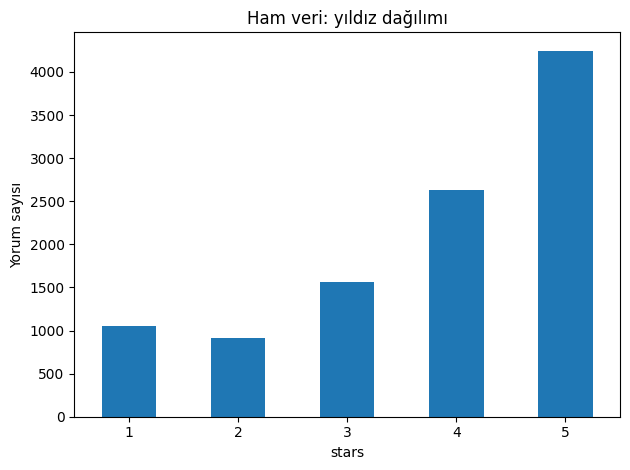

In [18]:
df.stars.value_counts().sort_index().plot.bar(title='Ham veri: yıldız dağılımı',rot=0)
plt.ylabel('Yorum sayısı');plt.tight_layout();plt.savefig(OUT/'yildiz_dagilimi.png');plt.show()

In [19]:
df['clean']=df.text.fillna('').str.replace(r'\\[nr]',' ',regex=True).str.lower()

In [20]:
df['clean']=df.clean.str.replace("n't",' not',regex=False)

In [21]:
df['clean']=df.clean.str.replace(r'[^\w\s]',' ',regex=True).str.replace(r'\d+',' ',regex=True)

In [22]:
df['clean']=df.clean.str.replace('_',' ',regex=False).str.replace(r'\s+',' ',regex=True).str.strip()

In [23]:
df['sentiment']=df.stars.map({1:'negative',2:'negative',3:'neutral',4:'positive',5:'positive'})

In [24]:
conflict=df.groupby('clean').sentiment.nunique()

In [25]:
bad_text=set(conflict[conflict>1].index)
reject=df.clean.eq('') | df.clean.isin(bad_text)
duplicate=(~reject)&df.clean.duplicated(keep='first')

In [26]:
df.loc[reject|duplicate].to_csv(OUT/'cikarilan_tekrar_ve_bos.csv',index=False)

In [27]:
print('Boş/çelişkili metin:',int(reject.sum()),'Ek birebir tekrar:',int(duplicate.sum()))

Boş/çelişkili metin: 2 Ek birebir tekrar: 28


In [28]:
df=df.loc[~reject&~duplicate].copy()

In [29]:
assert df.clean.is_unique

In [30]:
display(df[['text','clean','stars','sentiment']].head(3))

,text,clean,stars,sentiment
0,"After getting food poisoning at the Palms hotel, I was scared to eat at any ...",after getting food poisoning at the palms hotel i was scared to eat at any m...,5,positive
1,"""A feast worthy of Gods""\n\nBaccarnal Buffet in Caesar Palace is consider th...",a feast worthy of gods baccarnal buffet in caesar palace is consider the bes...,4,positive
2,The crab legs are better than the ones at Wicked Spoon and they have huge pr...,the crab legs are better than the ones at wicked spoon and they have huge pr...,4,positive


In [31]:
print('Temizlik sonrası:',len(df))

Temizlik sonrası: 10387


In [32]:
def language_of(text):
    try: return detect(text)
    except LangDetectException: return 'unknown'

In [33]:
df['language']=df.text.apply(language_of)

In [34]:
df[['row_id','review_id','language']].to_csv(OUT/'dil_tespiti.csv',index=False)

In [35]:
display(df.language.value_counts().to_frame('yorum'))

,yorum
language,
en,10343
es,10
zh-cn,7
ja,7
fr,5
de,4
ko,4
da,2
zh-tw,2


In [36]:
df.loc[df.language.ne('en')].to_csv(OUT/'ingilizce_olmayan.csv',index=False)

In [37]:
print('İngilizce dışı çıkarılan:',int(df.language.ne('en').sum()))

İngilizce dışı çıkarılan: 44


In [38]:
df=df.loc[df.language.eq('en')].copy().reset_index(drop=True)

In [39]:
print('İngilizce analiz kümesi:',len(df))

İngilizce analiz kümesi: 10343


In [40]:
stemmer=PorterStemmer();lemmatizer=WordNetLemmatizer()

In [41]:
df['lemma']=df.clean.apply(lambda s:' '.join(lemmatizer.lemmatize(w) for w in s.split()))

In [42]:
df['stem']=df.lemma.apply(lambda s:' '.join(stemmer.stem(w) for w in s.split()))

In [43]:
display(df[['clean','lemma','stem']].head(3))

,clean,lemma,stem
0,after getting food poisoning at the palms hotel i was scared to eat at any m...,after getting food poisoning at the palm hotel i wa scared to eat at any mor...,after get food poison at the palm hotel i wa scare to eat at ani more buffet...
1,a feast worthy of gods baccarnal buffet in caesar palace is consider the bes...,a feast worthy of god baccarnal buffet in caesar palace is consider the best...,a feast worthi of god baccarn buffet in caesar palac is consid the best buff...
2,the crab legs are better than the ones at wicked spoon and they have huge pr...,the crab leg are better than the one at wicked spoon and they have huge praw...,the crab leg are better than the one at wick spoon and they have huge prawn ...


In [44]:
df['word_count']=df.clean.str.split().str.len()

In [45]:
display(df.groupby('sentiment').agg(yorum=('text','size'),ortalama_yildiz=('stars','mean'),ortalama_kelime=('word_count','mean')).reindex(labels))

,yorum,ortalama_yildiz,ortalama_kelime
sentiment,,,
negative,1962,1.464832,149.660550
neutral,1554,3.000000,161.992278
positive,6827,4.616816,132.143987


In [46]:
df.to_csv(OUT/'temiz_yelp.csv',index=False)

In [47]:
print('Lemma ve stem sütunları hazır. Model girdisi: stem; sözlük duygu analizinin girdisi: clean.')

Lemma ve stem sütunları hazır. Model girdisi: stem; sözlük duygu analizinin girdisi: clean.


In [48]:
outer=StratifiedGroupKFold(n_splits=5,shuffle=True,random_state=42)

In [49]:
dev_idx,test_idx=next(outer.split(df.stem,df.sentiment,groups=df.user_id))

In [50]:
dev=df.iloc[dev_idx]

In [51]:
inner=StratifiedGroupKFold(n_splits=4,shuffle=True,random_state=42)

In [52]:
tr,va=next(inner.split(dev.stem,dev.sentiment,groups=dev.user_id))

In [53]:
train_idx=dev_idx[tr];val_idx=dev_idx[va]

In [54]:
df['split']='';df.loc[train_idx,'split']='train';df.loc[val_idx,'split']='validation';df.loc[test_idx,'split']='test'

In [55]:
display(pd.crosstab(df.split,df.sentiment).reindex(['train','validation','test']))

sentiment,negative,neutral,positive
split,,,
train,1181,912,4123
validation,400,331,1335
test,381,311,1369


In [56]:
for a,b in [('train','validation'),('train','test'),('validation','test')]:
    aa=df[df.split.eq(a)];bb=df[df.split.eq(b)]
    assert not set(aa.user_id)&set(bb.user_id)
    assert not set(aa.stem)&set(bb.stem), 'Köklenmiş metin tekrarı: grup ayrımı gerekli'

In [57]:
df.to_csv(OUT/'analiz_verisi.csv',index=False)

In [58]:
print('Kullanıcı ve model metni kesişimi: 0. Test seçim sürecine katılmadı.')

Kullanıcı ve model metni kesişimi: 0. Test seçim sürecine katılmadı.


In [59]:
stop=list(ENGLISH_STOP_WORDS-{'no','nor','not'})

In [60]:
stop=sorted(set(stemmer.stem(lemmatizer.lemmatize(w)) for w in stop)-{'no','nor','not'})

In [61]:
representations={'Count':CountVectorizer(stop_words=stop,dtype=np.float32),
 'Count_ngram':CountVectorizer(stop_words=stop,ngram_range=(1,2),dtype=np.float32),
 'TFIDF':TfidfVectorizer(stop_words=stop,dtype=np.float32),
 'TFIDF_ngram':TfidfVectorizer(stop_words=stop,ngram_range=(1,2),dtype=np.float32)}
matrices={};sizes=[]

In [65]:
for name,v in representations.items():
    a=v.fit_transform(df.loc[train_idx,'stem'])
    b=v.transform(df.loc[val_idx,'stem']);c=v.transform(df.loc[test_idx,'stem'])
    matrices[name]=(a,b,c)
    sizes.append({'representation':name,'train_rows':a.shape[0],'features':a.shape[1],'nonzero':a.nnz})
    joblib.dump(v,ROOT/'modeller'/f'{name}_vectorizer.joblib')

In [67]:
display(pd.DataFrame(sizes));pd.DataFrame(sizes).to_csv(OUT/'temsil_boyutlari.csv',index=False)

,representation,train_rows,features,nonzero
0,Count,6216,9764,311934
1,Count,6216,9764,311934
2,Count,6216,9764,311934
3,Count_ngram,6216,181878,692526
4,TFIDF,6216,9764,311934
5,TFIDF_ngram,6216,181878,692526


In [68]:
print('Sözlük ve IDF yalnız eğitimden öğrenildi. Seyrek matrisler bellekte korundu.')

Sözlük ve IDF yalnız eğitimden öğrenildi. Seyrek matrisler bellekte korundu.


In [69]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier,GradientBoostingClassifier
from sklearn.naive_bayes import MultinomialNB,BernoulliNB
from sklearn.base import clone

In [70]:
classifiers={'LogisticRegression':LogisticRegression(max_iter=1000,random_state=42),
 'KNeighborsClassifier':KNeighborsClassifier(n_jobs=2),
 'DecisionTreeClassifier':DecisionTreeClassifier(random_state=42),
 'RandomForestClassifier':RandomForestClassifier(random_state=42,n_jobs=2),
 'AdaBoostClassifier':AdaBoostClassifier(random_state=42),
 'GradientBoostingClassifier':GradientBoostingClassifier(random_state=42),
 'MultinomialNB':MultinomialNB(),'BernoulliNB':BernoulliNB()}

In [71]:
print('Sekiz model:',list(classifiers))

Sekiz model: ['LogisticRegression', 'KNeighborsClassifier', 'DecisionTreeClassifier', 'RandomForestClassifier', 'AdaBoostClassifier', 'GradientBoostingClassifier', 'MultinomialNB', 'BernoulliNB']


In [72]:
print('Diğer parametreler sklearn varsayılanıdır; ayarlar modeller/model_parametreleri.json içinde.')
(ROOT/'modeller/model_parametreleri.json').write_text(json.dumps({k:v.get_params() for k,v in classifiers.items()},indent=2,default=str),encoding='utf-8')

Diğer parametreler sklearn varsayılanıdır; ayarlar modeller/model_parametreleri.json içinde.


2452

In [73]:
results=[];best=None;best_f1=-1

In [74]:
y_train=df.loc[train_idx,'sentiment'];y_val=df.loc[val_idx,'sentiment']

In [75]:
for rep,(x_train,x_val,x_test) in matrices.items():
    for name,template in classifiers.items():
        t=time.time();model=clone(template).fit(x_train,y_train)
        pred=model.predict(x_val)
        row={'representation':rep,'model':name,'accuracy':accuracy_score(y_val,pred),
          'precision_macro':precision_score(y_val,pred,average='macro',zero_division=0),
          'recall_macro':recall_score(y_val,pred,average='macro',zero_division=0),
          'f1_macro':f1_score(y_val,pred,average='macro',zero_division=0),'seconds':time.time()-t}
        results.append(row)
        pd.DataFrame({'row_id':df.loc[val_idx,'row_id'],'true':y_val,'predicted':pred}).to_csv(OUT/f'validation_{rep}_{name}.csv',index=False)
        if row['f1_macro']>best_f1:
            best_f1=row['f1_macro'];best=(rep,name,model)
            joblib.dump(model,ROOT/'modeller/secilen_model.joblib')
        pd.DataFrame(results).to_csv(OUT/'32_model_dogrulama.csv',index=False)
        print(rep,name,'macro-F1=',round(row['f1_macro'],4),'sn=',round(row['seconds'],1),flush=True)

Count LogisticRegression macro-F1= 0.6401 sn= 1.6
Count KNeighborsClassifier macro-F1= 0.49 sn= 0.8
Count DecisionTreeClassifier macro-F1= 0.5028 sn= 2.2
Count RandomForestClassifier macro-F1= 0.4665 sn= 5.1
Count AdaBoostClassifier macro-F1= 0.4434 sn= 1.5
Count GradientBoostingClassifier macro-F1= 0.5725 sn= 17.2
Count MultinomialNB macro-F1= 0.6221 sn= 0.1
Count BernoulliNB macro-F1= 0.5811 sn= 0.1
Count_ngram LogisticRegression macro-F1= 0.6641 sn= 7.0
Count_ngram KNeighborsClassifier macro-F1= 0.4587 sn= 0.8
Count_ngram DecisionTreeClassifier macro-F1= 0.5369 sn= 10.4
Count_ngram RandomForestClassifier macro-F1= 0.4239 sn= 21.6
Count_ngram AdaBoostClassifier macro-F1= 0.506 sn= 7.4
Count_ngram GradientBoostingClassifier macro-F1= 0.5769 sn= 145.8
Count_ngram MultinomialNB macro-F1= 0.4465 sn= 0.1
Count_ngram BernoulliNB macro-F1= 0.2746 sn= 0.1
TFIDF LogisticRegression macro-F1= 0.6406 sn= 0.5
TFIDF KNeighborsClassifier macro-F1= 0.5347 sn= 0.7
TFIDF DecisionTreeClassifier macro-F

In [76]:
comparison=pd.DataFrame(results).sort_values('f1_macro',ascending=False)

In [77]:
display(comparison);print('Doğrulama seçimi:',best[:2])

,representation,model,accuracy,precision_macro,recall_macro,f1_macro,seconds
8,Count_ngram,LogisticRegression,0.803969,0.694843,0.651853,0.664105,7.030350
16,TFIDF,LogisticRegression,0.798645,0.703267,0.630818,0.640641,0.468180
0,Count,LogisticRegression,0.775895,0.653453,0.633806,0.640117,1.625193
24,TFIDF_ngram,LogisticRegression,0.799613,0.740335,0.617213,0.629553,4.713991
6,Count,MultinomialNB,0.786060,0.664600,0.621123,0.622122,0.085107
29,TFIDF_ngram,GradientBoostingClassifier,0.776379,0.671485,0.590970,0.608736,216.627223
21,TFIDF,GradientBoostingClassifier,0.760407,0.673509,0.563533,0.585795,52.634643
23,TFIDF,BernoulliNB,0.725073,0.627390,0.558104,0.581070,0.061291
7,Count,BernoulliNB,0.725073,0.627390,0.558104,0.581070,0.073042
13,Count_ngram,GradientBoostingClassifier,0.760407,0.669499,0.557300,0.576855,145.838381


Doğrulama seçimi: ('Count_ngram', 'LogisticRegression')


In [78]:
(ROOT/'modeller/secim.json').write_text(json.dumps({'representation':best[0],'model':best[1],'validation_f1_macro':best_f1},indent=2),encoding='utf-8')

115

In [79]:
rep,name,model=best

In [80]:
x_test=matrices[rep][2];y_test=df.loc[test_idx,'sentiment'];pred=model.predict(x_test)

In [81]:
test_metrics={'n':len(y_test),'accuracy':accuracy_score(y_test,pred),'precision_macro':precision_score(y_test,pred,average='macro',zero_division=0),'recall_macro':recall_score(y_test,pred,average='macro',zero_division=0),'f1_macro':f1_score(y_test,pred,average='macro',zero_division=0)}

In [82]:
display(pd.DataFrame([test_metrics]));print(classification_report(y_test,pred,labels=labels,zero_division=0))

,n,accuracy,precision_macro,recall_macro,f1_macro
0,2061,0.806405,0.696948,0.653132,0.669262


              precision    recall  f1-score   support

    negative       0.75      0.69      0.72       381
     neutral       0.47      0.32      0.39       311
    positive       0.87      0.95      0.91      1369

    accuracy                           0.81      2061
   macro avg       0.70      0.65      0.67      2061
weighted avg       0.79      0.81      0.79      2061



In [83]:
pd.DataFrame(classification_report(y_test,pred,labels=labels,output_dict=True,zero_division=0)).T.to_csv(OUT/'test_sinif_raporu.csv')

In [84]:
pd.DataFrame([test_metrics]).to_csv(OUT/'test_metrikleri.csv',index=False)

In [85]:
df.loc[test_idx,['row_id','stars','sentiment','text']].assign(predicted=pred).to_csv(OUT/'test_tahminleri.csv',index=False)

In [86]:
cm=confusion_matrix(y_test,pred,labels=labels)

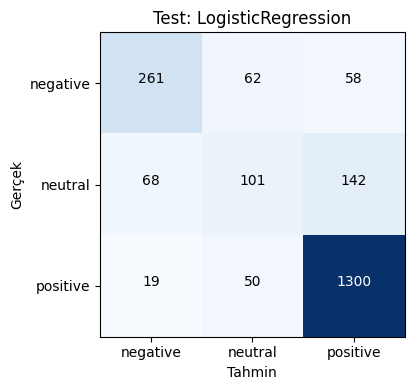

Eğitim çoğunluk sınıfı: positive Test baseline accuracy: 0.6642


In [88]:
fig,ax=plt.subplots(figsize=(5,4));ax.imshow(cm,cmap='Blues')
ax.set(xticks=range(3),yticks=range(3),xticklabels=labels,yticklabels=labels,xlabel='Tahmin',ylabel='Gerçek',title=f'Test: {name}')
for i in range(3):
 for j in range(3):ax.text(j,i,str(cm[i,j]),ha='center',color='white' if cm[i,j]>cm.max()/2 else 'black')
plt.tight_layout();plt.savefig(OUT/'test_confusion.png');plt.show()
pd.DataFrame(cm,index=labels,columns=labels).to_csv(OUT/'test_confusion.csv')
majority=y_train.value_counts().idxmax()
print('Eğitim çoğunluk sınıfı:',majority,'Test baseline accuracy:',round((y_test==majority).mean(),4))

In [89]:
tb=df.clean.apply(lambda s:TextBlob(s).sentiment)

In [90]:
df['polarity']=[x.polarity for x in tb];df['subjectivity']=[x.subjectivity for x in tb]

In [91]:
df['textblob_label']=np.select([df.polarity<0,df.polarity>0],['negative','positive'],default='neutral')

In [93]:
vader=SentimentIntensityAnalyzer()

In [94]:
vs=pd.DataFrame(df.clean.apply(vader.polarity_scores).tolist(),index=df.index)

In [95]:
df=pd.concat([df,vs.add_prefix('vader_')],axis=1)

In [96]:
df['vader_label']=np.select([df.vader_compound<=-.05,df.vader_compound>=.05],['negative','positive'],default='neutral')

In [97]:
display(df[['stars','polarity','subjectivity','vader_neg','vader_neu','vader_pos','vader_compound']].head())

,stars,polarity,subjectivity,vader_neg,vader_neu,vader_pos,vader_compound
0,5,0.367452,0.605702,0.092,0.657,0.251,0.9902
1,4,0.194222,0.532126,0.090,0.754,0.156,0.9973
2,4,-0.134722,0.731944,0.129,0.775,0.097,-0.6628
3,1,-0.325000,0.400000,0.089,0.911,0.000,-0.1695
4,5,0.362500,0.725000,0.031,0.742,0.227,0.9325


In [98]:
display(df.groupby('textblob_label').agg(yorum=('text','size'),ortalama_yildiz=('stars','mean')).reindex(labels))

,yorum,ortalama_yildiz
textblob_label,,
negative,961,1.932362
neutral,39,2.923077
positive,9343,3.969175


In [99]:
df.to_csv(OUT/'duygu_sonuclari.csv',index=False)

In [100]:
print('TextBlob polarity: <0 negatif, =0 nötr, >0 pozitif. VADER compound: ±0.05 eşikleri.')

TextBlob polarity: <0 negatif, =0 nötr, >0 pozitif. VADER compound: ±0.05 eşikleri.


In [101]:
rows=[]

In [102]:
for name,column in [('Yelp yıldız etiketi','sentiment'),('Yelp TextBlob','textblob_label'),('Yelp VADER','vader_label')]:
    rates=df[column].value_counts(normalize=True).reindex(labels,fill_value=0)*100
    rows.append({'kaynak':name,'n':len(df),**rates.to_dict(),'durum':'Hesaplandı'})
rates=pd.DataFrame(rows);display(rates);rates.to_csv(OUT/'yelp_duygu_dagilimi.csv',index=False)
agreement=[]

,kaynak,n,negative,neutral,positive,durum
0,Yelp yıldız etiketi,10343,18.969351,15.024654,66.005994,Hesaplandı
1,Yelp TextBlob,10343,9.291308,0.377067,90.331625,Hesaplandı
2,Yelp VADER,10343,11.573045,1.208547,87.218409,Hesaplandı


In [103]:
for method,col in [('TextBlob','textblob_label'),('VADER','vader_label')]:
    p=df.loc[test_idx,col]
    agreement.append({'method':method,'n':len(test_idx),'accuracy':accuracy_score(y_test,p),'f1_macro':f1_score(y_test,p,average='macro',zero_division=0)})

In [104]:
display(pd.DataFrame(agreement));pd.DataFrame(agreement).to_csv(OUT/'duygu_test_uyumu.csv',index=False)

,method,n,accuracy,f1_macro
0,TextBlob,2061,0.704998,0.417264
1,VADER,2061,0.725861,0.467594


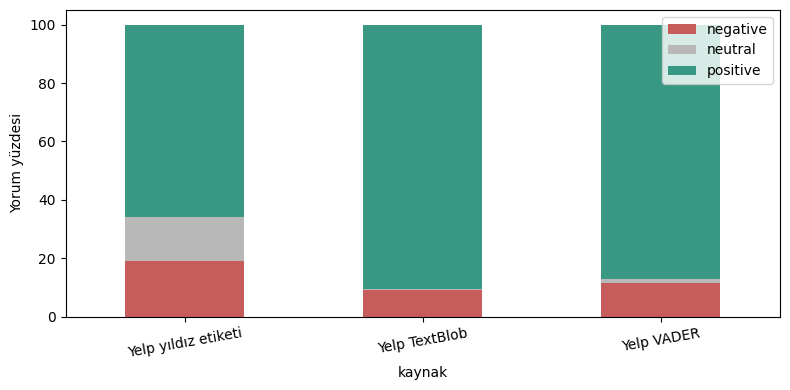

Etiket dağılımı, model doğruluğu değildir. Yöntemler aynı test satırlarında ayrıca karşılaştırıldı.


In [107]:
rates.iloc[:3].set_index('kaynak')[labels].plot.bar(stacked=True,color=['#c75c5c','#b8b8b8','#399884'],figsize=(8,4),rot=10)
plt.ylabel('Yorum yüzdesi');plt.tight_layout();plt.savefig(OUT/'duygu_karsilastirma.png');plt.show()
print('Etiket dağılımı, model doğruluğu değildir. Yöntemler aynı test satırlarında ayrıca karşılaştırıldı.')

In [108]:
from wordcloud import WordCloud,STOPWORDS
from PIL import Image

In [111]:
mask=np.asarray(Image.open(ROOT/'cloud.png').convert('L'))

In [112]:
groups={'5_yildiz':df.stars.eq(5),'1_yildiz':df.stars.eq(1),'TextBlob_pozitif':df.textblob_label.eq('positive'),'TextBlob_negatif':df.textblob_label.eq('negative')}

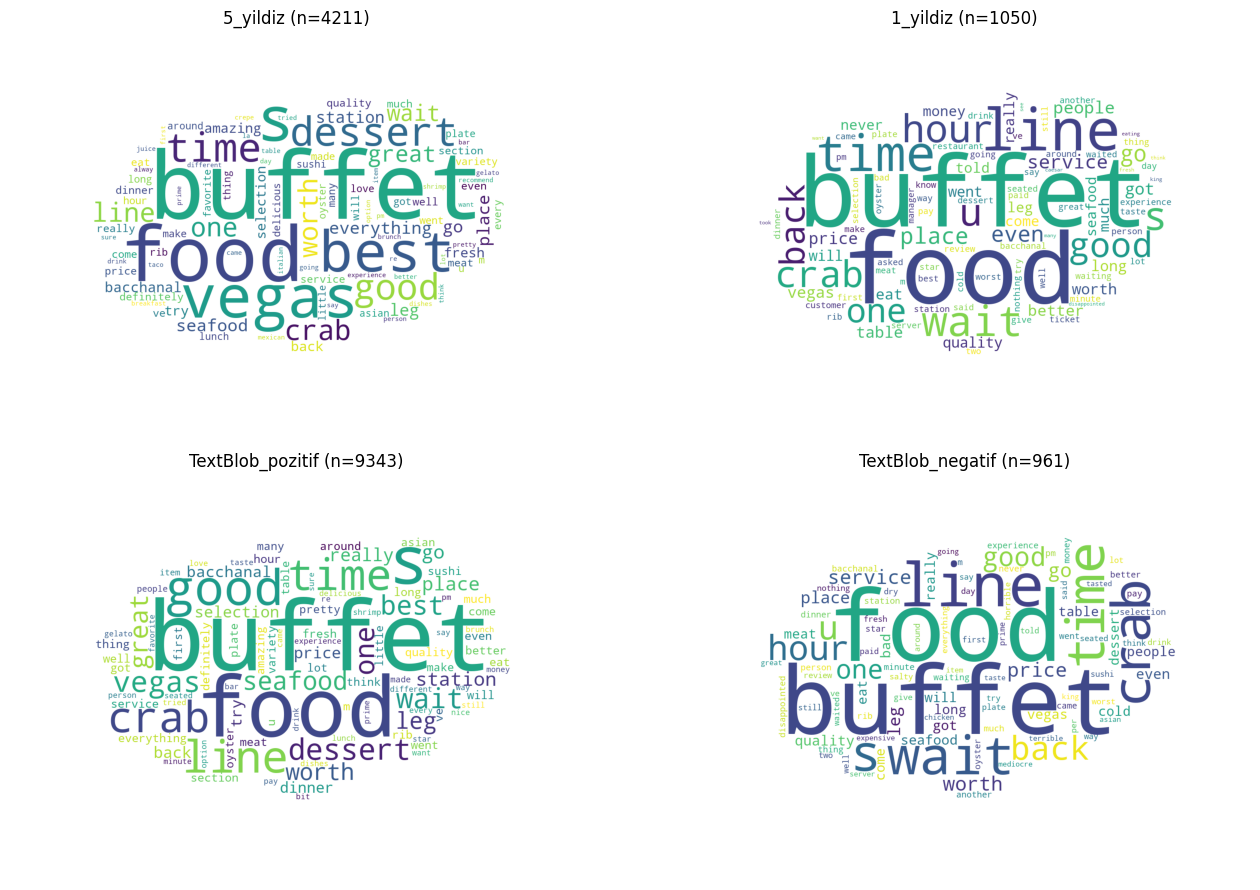

In [115]:
fig,axes=plt.subplots(2,2,figsize=(14,9))
for ax,(name,condition) in zip(axes.flat,groups.items()):
    text=' '.join(df.loc[condition,'clean'].tolist())
    wc=WordCloud(background_color='white',mask=mask,stopwords=STOPWORDS,collocations=False,random_state=42,max_words=100).generate(text)
    wc.to_file(str(OUT/f'wordcloud_{name}.png'));ax.imshow(wc);ax.set_title(f'{name} (n={condition.sum()})');ax.axis('off')
plt.tight_layout();plt.savefig(OUT/'kelime_bulutlari.png');plt.show()

In [116]:
print('Dört bulut üretildi. Series repr yerine gerçek metinler boşlukla birleştirildi.')

Dört bulut üretildi. Series repr yerine gerçek metinler boşlukla birleştirildi.


In [117]:
ngram_tables=[]

In [119]:
for label in ['positive','negative']:
    texts=df.loc[df.textblob_label.eq(label),'clean']
    for n in [2,3]:
        v=CountVectorizer(ngram_range=(n,n),stop_words=None)
        x=v.fit_transform(texts);freq=np.asarray(x.sum(axis=0)).ravel()
        table=pd.DataFrame({'phrase':v.get_feature_names_out(),'count':freq}).sort_values(['count','phrase'],ascending=[False,True]).head(15)
        table['sentiment']=label;table['n']=n;ngram_tables.append(table)
        display(table.head(10))

,phrase,count,sentiment,n
157427,of the,5298,positive,2
119505,it was,4454,positive,2
229346,the food,3854,positive,2
52925,crab legs,3377,positive,2
11522,and the,3340,positive,2
228191,the best,3246,positive,2
86701,for the,2853,positive,2
111566,if you,2830,positive,2
64920,do not,2784,positive,2
61436,did not,2734,positive,2


,phrase,count,sentiment,n
581151,the best buffet,1144,positive,3
588356,the food was,1073,positive,3
426264,one of the,966,positive,3
97907,buffet in vegas,902,positive,3
82141,best buffet in,802,positive,3
588149,the food is,717,positive,3
584823,the crab legs,692,positive,3
414456,of the food,600,positive,3
286933,if you re,579,positive,3
622731,this place is,558,positive,3


,phrase,count,sentiment,n
24637,of the,394,negative,2
18555,it was,377,negative,2
36055,the food,367,negative,2
2035,and the,286,negative,2
13287,for the,285,negative,2
38880,to the,273,negative,2
10000,do not,262,negative,2
41635,was not,246,negative,2
8375,crab legs,245,negative,2
9331,did not,218,negative,2


,phrase,count,sentiment,n
60804,the food was,128,negative,3
41474,not worth the,88,negative,3
42604,of the food,68,negative,3
41459,not worth it,62,negative,3
60365,the crab legs,57,negative,3
65300,this place is,50,negative,3
68079,to wait in,47,negative,3
60754,the food is,45,negative,3
43889,one of the,44,negative,3
29547,in line for,43,negative,3


In [120]:
ngrams=pd.concat(ngram_tables,ignore_index=True);ngrams.to_csv(OUT/'ikili_uclu_kelimeler.csv',index=False)

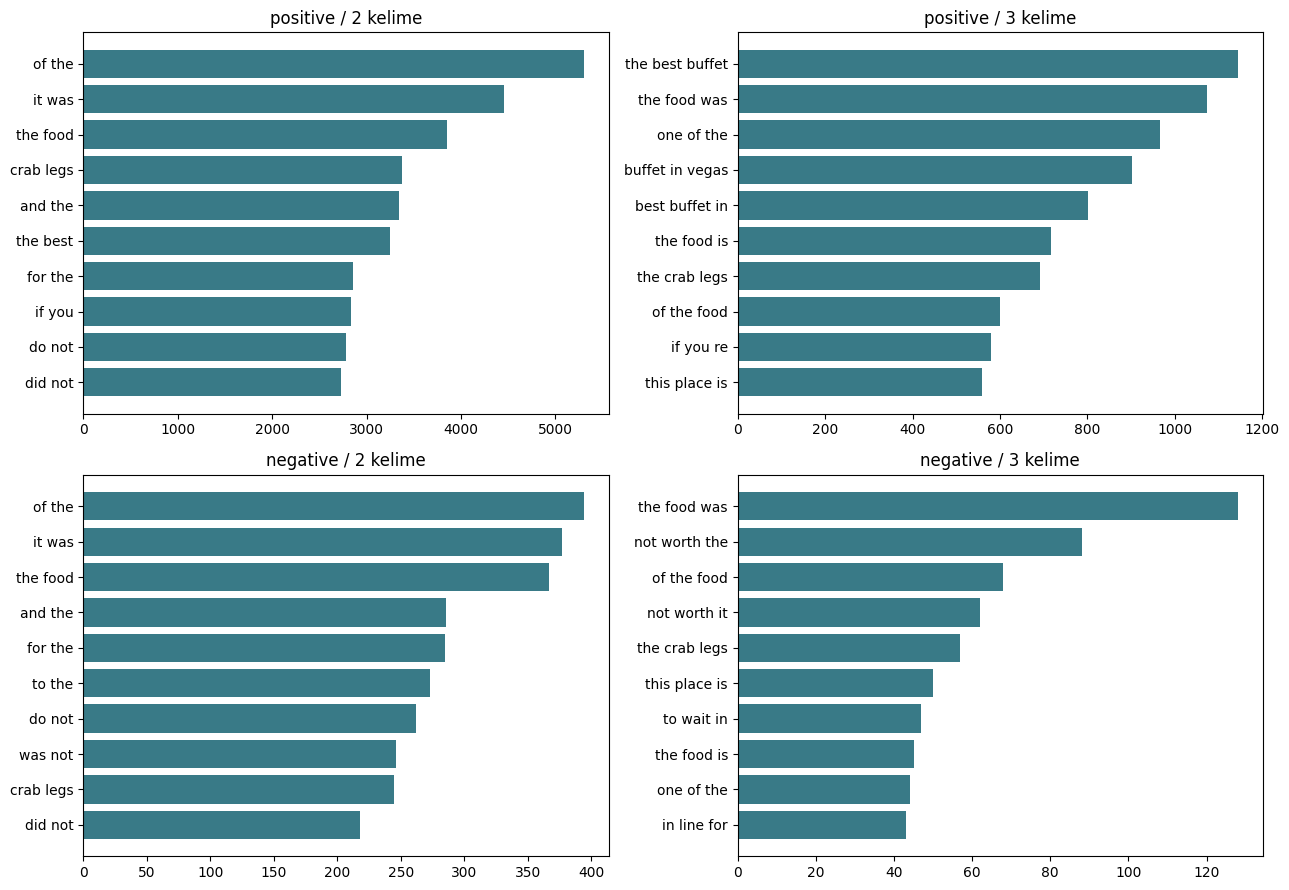

In [122]:
fig,axes=plt.subplots(2,2,figsize=(13,9))
for ax,table in zip(axes.flat,ngram_tables):
    t=table.head(10).iloc[::-1];ax.barh(t.phrase,t['count'],color='#397a87');ax.set_title(f"{t.sentiment.iloc[0]} / {t.n.iloc[0]} kelime")
plt.tight_layout();plt.savefig(OUT/'ngramlar.png');plt.show()

In [123]:
print('Ardışık 2 ve 3 sözcük; stopword çıkarılmadı, yapay komşuluk oluşturulmadı.')

Ardışık 2 ve 3 sözcük; stopword çıkarılmadı, yapay komşuluk oluşturulmadı.


In [124]:
themes={'Bekleme':r'\b(wait|waiting|queue|line)\b','Fiyat':r'\b(expensive|price|cost|overpriced)\b','Tuz':r'\b(salt|salty)\b','Servis':r'\b(waiter|waitress|server|service|rude)\b','Tuvalet':r'\b(restroom|bathroom|toilet)\b','Hastalık ifadesi':r'\b(poisoning|sick|vomit|diarrhea)\b'}
theme_rows=[]

In [125]:
for theme,pattern in themes.items():
    hit=df.clean.str.contains(pattern,regex=True)
    theme_rows.append({'theme':theme,'all_mentions':int(hit.sum()),'negative_star_mentions':int((hit&df.sentiment.eq('negative')).sum())})
theme_table=pd.DataFrame(theme_rows).sort_values('negative_star_mentions',ascending=False)

C:\Users\cetin\AppData\Local\Temp\ipykernel_21732\2761215473.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  hit=df.clean.str.contains(pattern,regex=True)


In [126]:
display(theme_table);theme_table.to_csv(OUT/'isletme_tema_sayilari.csv',index=False)

,theme,all_mentions,negative_star_mentions
0,Bekleme,4689,950
1,Fiyat,3374,772
3,Servis,3125,689
2,Tuz,629,210
5,Hastalık ifadesi,187,122
4,Tuvalet,65,22


In [127]:
print('Bunlar anahtar kelime eşleşmesidir; şikâyet veya sağlık vakası sayısı değildir. Başka işletmeye ait ifade ve olumsuzlama içerebilir.')

Bunlar anahtar kelime eşleşmesidir; şikâyet veya sağlık vakası sayısı değildir. Başka işletmeye ait ifade ve olumsuzlama içerebilir.


In [128]:
from bs4 import BeautifulSoup as soup

In [130]:
arsiv=pd.read_csv(ROOT/'kaynak/foursquare_arsiv/arsiv_kopyalari.csv',dtype=str)

In [131]:
print('Arşiv kopyası:',len(arsiv),'| yıllar:',arsiv.snapshot.str[:4].value_counts().sort_index().to_dict())

Arşiv kopyası: 286 | yıllar: {'2013': 1, '2014': 1, '2015': 87, '2017': 1, '2018': 1, '2020': 88, '2021': 38, '2022': 29, '2023': 11, '2024': 29}


In [132]:
ornek=arsiv.iloc[0]
sayfa=ROOT/'kaynak/foursquare_arsiv'/(hashlib.sha1((ornek.snapshot+ornek.source_url).encode()).hexdigest()[:16]+'.html')

In [133]:
sp=soup(sayfa.read_text(encoding='utf8',errors='ignore'),'html.parser')

In [134]:
ipuclari=sp.select('li.tip')

In [135]:
print('Örnek sayfa:',ornek.source_url,ornek.snapshot,'| ipucu:',len(ipuclari))

Örnek sayfa: https://foursquare.com/v/bacchanal-buffet/504e861fe4b06a59881632b0 20131105135004 | ipucu: 50


In [136]:
print('İlk ipucu:',ipuclari[0].select('p.tipText')[0].text)

İlk ipucu: The biggest and best buffet in Vegas.   Hail Caesar!


In [137]:
fsq=pd.read_csv(ROOT/'data/foursquare_tips.csv')

In [138]:
fsq['date']=pd.to_datetime(fsq.date_text,format='%B %d, %Y',errors='coerce')

In [139]:
display(fsq[['tip_id','text','date_text','source_url']].head())

,tip_id,text,date_text,source_url
0,5049303be4b01b47ba44a95b,"The glass-themed dining area is my favorite, the steel and wood-themed dinin...","September 6, 2012",https://foursquare.com/v/bacchanal-buffet/504e861fe4b06a59881632b0?tipsPage=2
1,504be15de4b050eb2a56e572,Lighting Design Studio is proud to have been a part of the architectural des...,"September 9, 2012",https://foursquare.com/v/bacchanal-buffet/504e861fe4b06a59881632b0?tipsPage=3
2,504e86bfe4b0b950827ac34f,There's something for everyone here! Very beautiful and great service! Try t...,"September 11, 2012",https://foursquare.com/v/bacchanal-buffet/504e861fe4b06a59881632b0?tipsPage=3
3,504fc9e1e4b0c7d0d906b67e,Opening Day! Food is fresh and super yummy! Staff very friendly - great place,"September 11, 2012",https://foursquare.com/v/bacchanal-buffet/504e861fe4b06a59881632b0?tipsPage=3
4,5053e18de4b012cb81bc28c2,It's all good. Our waitress Christine was funny. And Caesars has bins in the...,"September 15, 2012",https://foursquare.com/v/bacchanal-buffet/504e861fe4b06a59881632b0?tipsPage=3


In [140]:
print('Tekil ipucu:',fsq.shape,'| tekrar eden kimlik:',int(fsq.tip_id.duplicated().sum()))

Tekil ipucu: (396, 7) | tekrar eden kimlik: 0


In [141]:
print('Tarih aralığı:',fsq.date.min().date(),'-',fsq.date.max().date(),'| İngilizce tarihi okunamayan:',int(fsq.date.isna().sum()))

Tarih aralığı: 2012-09-06 - 2022-09-26 | İngilizce tarihi okunamayan: 63


In [143]:
fsq['clean']=fsq.text.fillna('').str.replace(r'\\[nr]',' ',regex=True).str.lower()
fsq['clean']=fsq.clean.str.replace("n't",' not',regex=False)
fsq['clean']=fsq.clean.str.replace(r'[^\w\s]',' ',regex=True).str.replace(r'\d+',' ',regex=True)
fsq['clean']=fsq.clean.str.replace('_',' ',regex=False).str.replace(r'\s+',' ',regex=True).str.strip()
fsq['language']=fsq.text.apply(language_of)

In [144]:
print('Dil dağılımı:',fsq.language.value_counts().head(8).to_dict())

Dil dağılımı: {'en': 316}


In [145]:
fsq[['tip_id','text','language']].to_csv(OUT/'foursquare_dil_tespiti.csv',index=False)

In [146]:
bos=fsq.clean.eq('');tekrar=fsq.clean.duplicated(keep='first')&~bos

In [147]:
print('İngilizce dışı:',int(fsq.language.ne('en').sum()),'| boş:',int(bos.sum()),'| birebir metin tekrarı:',int(tekrar.sum()))

İngilizce dışı: 0 | boş: 0 | birebir metin tekrarı: 0


In [148]:
fsq=fsq[fsq.language.eq('en')&~bos&~tekrar].copy()

In [149]:
tb=fsq.clean.apply(lambda s:TextBlob(s).sentiment)

In [150]:
fsq['polarity']=[x.polarity for x in tb];fsq['subjectivity']=[x.subjectivity for x in tb]
fsq['textblob_label']=np.select([fsq.polarity<0,fsq.polarity>0],['negative','positive'],default='neutral')

In [151]:
vs=pd.DataFrame(fsq.clean.apply(vader.polarity_scores).tolist(),index=fsq.index)

In [152]:
fsq=pd.concat([fsq,vs.add_prefix('vader_')],axis=1)
fsq['vader_label']=np.select([fsq.vader_compound<=-.05,fsq.vader_compound>=.05],['negative','positive'],default='neutral')

In [153]:
display(fsq[['text','polarity','subjectivity','vader_compound','textblob_label','vader_label']].head())

,text,polarity,subjectivity,vader_compound,vader_compound,textblob_label,vader_label
0,"The glass-themed dining area is my favorite, the steel and wood-themed dinin...",0.500000,0.750000,0.9260,0.9260,positive,positive
1,Lighting Design Studio is proud to have been a part of the architectural des...,0.600000,1.000000,0.7964,0.7964,positive,positive
2,There's something for everyone here! Very beautiful and great service! Try t...,0.933333,0.916667,0.9225,0.9225,positive,positive
3,Opening Day! Food is fresh and super yummy! Staff very friendly - great place,0.480208,0.641667,0.9550,0.9550,positive,positive
4,It's all good. Our waitress Christine was funny. And Caesars has bins in the...,0.359375,0.746875,0.9062,0.9062,positive,positive


In [154]:
display(pd.crosstab(fsq.textblob_label,fsq.vader_label))

vader_label,negative,neutral,positive
textblob_label,,,
negative,16,5,9
neutral,4,24,9
positive,12,15,222


In [155]:
fsq.to_csv(OUT/'foursquare_duygu_sonuclari.csv',index=False)

In [156]:
print('Analiz edilen İngilizce Foursquare ipucu:',len(fsq))

Analiz edilen İngilizce Foursquare ipucu: 316


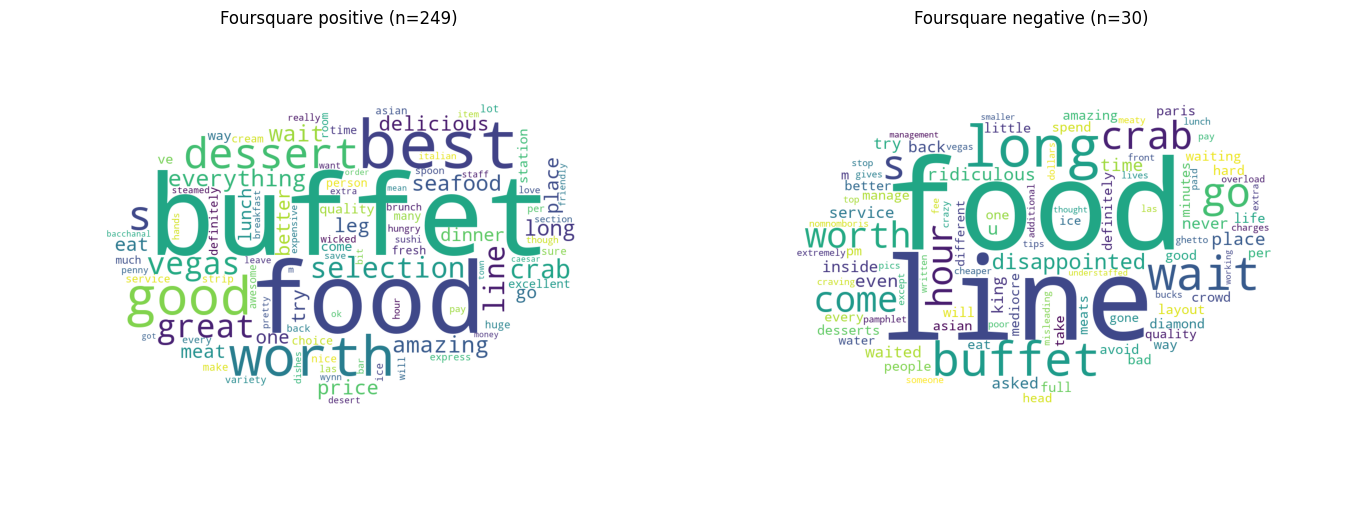

In [157]:
fig,axes=plt.subplots(1,2,figsize=(14,5))
for ax,label in zip(axes,['positive','negative']):
    texts=fsq.loc[fsq.textblob_label.eq(label),'clean']
    wc=WordCloud(background_color='white',mask=mask,stopwords=STOPWORDS,collocations=False,random_state=42,max_words=100).generate(' '.join(texts))
    wc.to_file(str(OUT/f'foursquare_wordcloud_{label}.png'));ax.imshow(wc);ax.set_title(f'Foursquare {label} (n={len(texts)})');ax.axis('off')
plt.tight_layout();plt.savefig(OUT/'foursquare_kelime_bulutlari.png');plt.show()

In [158]:
fsq_ngrams=[]
for label in ['positive','negative']:
    texts=fsq.loc[fsq.textblob_label.eq(label),'clean']
    for n in [2,3]:
        v=CountVectorizer(ngram_range=(n,n));x=v.fit_transform(texts);freq=np.asarray(x.sum(axis=0)).ravel()
        table=pd.DataFrame({'phrase':v.get_feature_names_out(),'count':freq}).sort_values(['count','phrase'],ascending=[False,True]).head(10)
        table['sentiment']=label;table['n']=n;fsq_ngrams.append(table)
fsq_ngrams=pd.concat(fsq_ngrams,ignore_index=True);fsq_ngrams.to_csv(OUT/'foursquare_ikili_uclu_kelimeler.csv',index=False)

In [159]:
display(fsq_ngrams.groupby(['sentiment','n']).head(5))

,phrase,count,sentiment,n
0,best buffet,32,positive,2
1,the best,29,positive,2
2,buffet in,21,positive,2
3,in vegas,19,positive,2
4,for the,17,positive,2
10,best buffet in,15,positive,3
11,the best buffet,11,positive,3
12,buffet in vegas,10,positive,3
13,on the strip,9,positive,3
14,in las vegas,8,positive,3


In [164]:
rows=[]
for name,frame,column in [('Yelp yıldız etiketi',df,'sentiment'),('Yelp TextBlob',df,'textblob_label'),('Yelp VADER',df,'vader_label'),('Foursquare TextBlob',fsq,'textblob_label'),('Foursquare VADER',fsq,'vader_label')]:
    rates=frame[column].value_counts(normalize=True).reindex(labels,fill_value=0)*100
    rows.append({'kaynak':name,'n':len(frame),**rates.to_dict(),'durum':'Hesaplandı'})
rows.append({'kaynak':'Twitter','n':np.nan,'negative':np.nan,'neutral':np.nan,'positive':np.nan,'durum':'Tweet verisine erişim yok; hesaplanmadı'})

In [168]:
rates=pd.DataFrame(rows);display(rates.round(2));rates.to_csv(OUT/'platform_karsilastirma.csv',index=False)

,kaynak,n,negative,neutral,positive,durum
0,Yelp yıldız etiketi,10343.0,18.97,15.02,66.01,Hesaplandı
1,Yelp TextBlob,10343.0,9.29,0.38,90.33,Hesaplandı
2,Yelp VADER,10343.0,11.57,1.21,87.22,Hesaplandı
3,Foursquare TextBlob,316.0,9.49,11.71,78.80,Hesaplandı
4,Foursquare VADER,316.0,10.13,13.92,75.95,Hesaplandı
5,Twitter,NaN,NaN,NaN,NaN,Tweet verisine erişim yok; hesaplanmadı


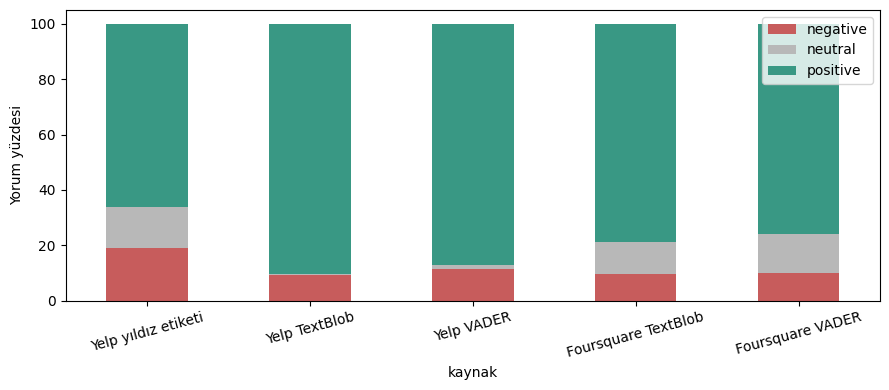

In [171]:
rates.dropna().set_index('kaynak')[labels].plot.bar(stacked=True,color=['#c75c5c','#b8b8b8','#399884'],figsize=(9,4),rot=15)
plt.ylabel('Yorum yüzdesi');plt.tight_layout();plt.savefig(OUT/'platform_karsilastirma.png');plt.show()

In [174]:
tema=[]
for theme,pattern in themes.items():
    hit=fsq.clean.str.contains(pattern,regex=True)
    tema.append({'theme':theme,'Yelp_100_yorumda':100*df.clean.str.contains(pattern,regex=True).mean(),'Foursquare_100_ipucunda':100*hit.mean(),'Foursquare_negatif_ipucu':int((hit&fsq.textblob_label.eq('negative')).sum())})

C:\Users\cetin\AppData\Local\Temp\ipykernel_21732\874139432.py:3: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  hit=fsq.clean.str.contains(pattern,regex=True)
C:\Users\cetin\AppData\Local\Temp\ipykernel_21732\874139432.py:4: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  tema.append({'theme':theme,'Yelp_100_yorumda':100*df.clean.str.contains(pattern,regex=True).mean(),'Foursquare_100_ipucunda':100*hit.mean(),'Foursquare_negatif_ipucu':int((hit&fsq.textblob_label.eq('negative')).sum())})


In [175]:
tema=pd.DataFrame(tema).round(2);display(tema);tema.to_csv(OUT/'platform_tema_karsilastirma.csv',index=False)


,theme,Yelp_100_yorumda,Foursquare_100_ipucunda,Foursquare_negatif_ipucu
0,Bekleme,45.34,15.82,11
1,Fiyat,32.62,9.49,2
2,Tuz,6.08,0.63,1
3,Servis,30.21,5.06,4
4,Tuvalet,0.63,0.32,0
5,Hastalık ifadesi,1.81,0.32,0


In [176]:
from pathlib import Path
import json,joblib,numpy as np,pandas as pd
from IPython.display import display

In [177]:
ROOT=Path.cwd();OUT=ROOT/'sonuclar'

In [178]:
selection=json.loads((ROOT/'modeller/secim.json').read_text())

In [179]:
loaded=joblib.load(ROOT/'modeller/secilen_model.joblib')

In [180]:
saved_vector=joblib.load(ROOT/'modeller'/f"{selection['representation']}_vectorizer.joblib")

In [181]:
test_rows=pd.read_csv(OUT/'test_tahminleri.csv')

In [182]:
prepared=pd.read_csv(OUT/'analiz_verisi.csv').set_index('row_id').loc[test_rows.row_id]

In [183]:
again=loaded.predict(saved_vector.transform(prepared.stem))

In [184]:
assert np.array_equal(test_rows.predicted,again)

In [185]:
print('Kaydedilen model ve vektörleştirici yeniden açıldı; tüm test tahminleri aynı.')

Kaydedilen model ve vektörleştirici yeniden açıldı; tüm test tahminleri aynı.


In [186]:
display(test_rows[['text','sentiment','predicted']].head(4))

,text,sentiment,predicted
0,I would give this infinite stars if I could. My family has a diamond card at...,positive,positive
1,Came for dinner at $55 per person at around 5pm (practically no line at all)...,positive,positive
2,I have been craving getting down with a buffet for a LONG time now - blame i...,neutral,positive
3,I would recommend this buffet to those with an expensive palate. It is usual...,neutral,positive


In [187]:
print('32 deney; test satırı:',len(test_rows),'Model:',selection['representation'],selection['model'])

32 deney; test satırı: 2061 Model: Count_ngram LogisticRegression


Gerçek sonuç: Kaydedilen model ve vektörleştirici yeniden açıldı; tüm test tahminleri aynı.

32 deney; test satırı: 2061 Model: Count_ngram LogisticRegression

Türkçe yorum: Model ve ona ait eğitim sözlüğü birlikte saklanır. Yeniden yükleme tüm test üzerinde doğrulanır. Bu model yalnız aynı İngilizce restoran yorumları bağlamında değerlendirilmiştir; Türkçe başarı iddiası yoktur.

# Sonuç ve işletme önerileri
Temiz İngilizce analiz kümesi 10,343 yorumdur. Model yalnız metni kullanır; yıldızlar hedeftir. Doğrulama macro-F1 ile Count_ngram + LogisticRegression seçildi. Test doğruluğu %80.64, macro-F1 0.6693.

Nötr sınıf recall 0.3248; genel accuracy tek başına nötr yorum başarısını açıklamaz. Sınıf dengesizliği yüzünden macro-F1 ayrıca raporlanır. Yıldız etiketiyle sözlük duygu skorunun uyuşmaması her zaman yazılım hatası değildir; yorum aynı anda övgü ve eleştiri içerebilir.

İşletme için: düşük yıldızlı yorumlarda geçen bekleme, fiyat ve servis ifadeleri insan incelemesine alınmalı; doğrulanan konular için bekleme süresi ölçümü, fiyat/içerik açıklaması ve servis geri bildirim süreci tasarlanmalıdır. Tema CSV’si yalnız sözcük eşleşmesi sayar, gerçek şikâyet veya sağlık vakası saymaz. Başka işletmeye ait deneyimler bu restoranın olayı gibi aktarılmamalıdır.

Gelecek çalışma: zaman sıralı dış test, elle etiketlenmiş duygu örnekleri ve nötr sınıf hata incelemesi; test skorunu görüp bu deneyin parametreleri değiştirilmedi. Bu deney yeni kullanıcı gruplarına ayrılmış rastgele testtir, geleceğe dönük başarı kanıtı değildir.

Foursquare (26 Eylül 2026'da eklendi): Canlı sayfa giriş istediği için aynı mekân sayfasının Wayback Machine'deki 286 kamuya açık kopyası kazındı; 396 tekil ipucundan 316 İngilizce ipucu analiz edildi. Foursquare ipuçları Yelp yorumlarından çok daha kısadır (medyan 16 / 98 kelime). TextBlob pozitif oranı Yelp'te %90.3, Foursquare'de %78.8; fark büyük ölçüde nötr orandan gelir (%0.4 / %11.7), çünkü kısa ipuçlarında sözlük çoğu zaman duygu kelimesi bulamaz. Negatif oran iki platformda yakındır (%9.3 / %9.5). 30 negatif ipucunun 11 tanesi uzun kuyruk/beklemeden söz ediyor; bu, Yelp'teki bekleme temasıyla aynı yönde bir işarettir. Arşiv yalnız yakalanan sayfaları içerir; Foursquare'deki tüm ipuçlarının tamamı olduğu iddia edilmez.

Twitter: Tweet verisi elde edilemedi. X arama sayfası giriş istiyor, API ücretli; arşivdeki arama sayfaları yalnız JavaScript kabuğu içeriyor. Twitter duygu analizi ve üç platformun tam karşılaştırması bu nedenle yapılmadı; eski sunumdaki Twitter yüzdeleri kullanılmadı.

# Kaynaklar
Asıl ders notebook’ları ve hücreler: DERS_KAYNAKLARI.json, ders_kaynaklari/.
Kullanıcı yönergesi ve görseller: kaynak/.
NLTK VADER: https://www.nltk.org/api/nltk.sentiment.SentimentIntensityAnalyzer.html
Vektörleştirici: https://scikit-learn.org/1.5/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html
Foursquare arşiv kopyaları: Internet Archive Wayback Machine, https://web.archive.org/ (liste: kaynak/foursquare_arsiv/arsiv_kopyalari.csv).
Örnek sunumla ilişkili kaynak proje: https://github.com/yalinyener/NLPClassification . Başkasının sonuçları kendi ölçümümüz yerine kullanılmadı.
Click to add a cell.